# Baseline & Iterative Modeling

Chỉ dùng `train_df` từ `get_split()`. Holdout `test_df` để dành cho notebook đánh giá, không đụng tới ở đây.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.churn_classification.data_split import RANDOM_STATE, get_split
from src.churn_classification.preprocessing import build_preprocessor, compute_scale_pos_weight, split_X_y

train_df, _test_df_do_not_touch = get_split()
X_train, y_train = split_X_y(train_df)
print(f"X_train: {X_train.shape}, positive rate: {y_train.mean():.4f}")


Loading cached split from /home/tthhieu/survival-analysis/data/processed/churn_classification (created earlier). Delete this folder and re-run to regenerate with current TEST_SIZE/RANDOM_STATE.
X_train: (5977, 19), positive rate: 0.2659


In [2]:
# Cung mot StratifiedKFold config nhu notebook 02 -- vi X_train/y_train bat nguon tu cung
# 1 file train.csv da persist, cac fold nay deterministic va giong het nhau giua cac notebook.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "PR-AUC": "average_precision",
    "ROC-AUC": "roc_auc",
    "F2": make_scorer(fbeta_score, beta=2, zero_division=0),
}


def summarize_cv(cv_results: dict, label: str) -> pd.DataFrame:
    rows = []
    for metric in scoring:
        val_scores = cv_results[f"test_{metric}"]
        row = {"model": label, "metric": metric, "cv_mean": val_scores.mean(), "cv_std": val_scores.std()}
        if f"train_{metric}" in cv_results:
            row["train_mean"] = cv_results[f"train_{metric}"].mean()
            row["overfit_gap"] = row["train_mean"] - row["cv_mean"]
        rows.append(row)
    return pd.DataFrame(rows)


## 1. Mốc "no-skill" — DummyClassifier

Trước khi tin bất kỳ con số PR-AUC/F2 nào, cần một mốc sàn: model không học gì từ `X`, chỉ dựa vào phân phối lớp của `y`. `DummyClassifier(strategy="stratified")` bỏ qua hoàn toàn `X` nên không cần preprocessing ở bước này.

Kỳ vọng: PR-AUC của baseline không skill phải xấp xỉ prevalence (~0.2659). Nếu số đo ra lệch nhiều, khả năng cao là bug ở scoring/CV chứ không phải ở model.

In [3]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy_cv = cross_validate(dummy, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
dummy_summary = summarize_cv(dummy_cv, "Dummy (stratified)")
dummy_summary


,model,metric,cv_mean,cv_std,train_mean,overfit_gap
0,Dummy (stratified),PR-AUC,0.265415,0.003134,0.266296,0.000881
1,Dummy (stratified),ROC-AUC,0.498479,0.008474,0.500907,0.002428
2,Dummy (stratified),F2,0.266695,0.012461,0.262989,-0.003706


## 2. Các model ứng viên — so sánh có kiểm soát

Một preprocessing pipeline, một bộ CV fold, một bộ scoring, chỉ đổi thuật toán qua mỗi vòng. Nếu số liệu đổi thì chắc chắn là do bản thân model, không lẫn với thay đổi feature/CV/metric.

- **Logistic Regression** (`class_weight="balanced"`, không SMOTE) làm baseline interpretable.
- **LightGBM / XGBoost / CatBoost**: `scale_pos_weight` dùng lại con số tính một lần trên toàn train pool. Đây chưa phải tuning: cấu hình cố tình để dè dặt (`max_depth=6`, `n_estimators=300`, `learning_rate=0.05`) vì train pool chỉ ~6000 dòng, cây sâu/nhiều cây trên dữ liệu nhỏ rất dễ overfit. Mục tiêu là xem non-linearity của tree model có mang lại lợi ích gì trước khi bỏ công tune bài bản.

Preprocessing được bọc chung trong cùng một `Pipeline` với từng model rồi mới đưa vào `cross_validate`, để imputer/scaler/encoder fit lại từ đầu ở mỗi fold.

In [4]:
scale_pos_weight_train = compute_scale_pos_weight(y_train)
print(f"scale_pos_weight tren toan bo train pool: {scale_pos_weight_train:.4f}")

COMMON_TREE_KWARGS = dict(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=RANDOM_STATE)

CANDIDATE_MODELS = {
    "LogisticRegression (balanced)": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
    ),
    "LightGBM": LGBMClassifier(**COMMON_TREE_KWARGS, scale_pos_weight=scale_pos_weight_train, verbose=-1),
    "XGBoost": XGBClassifier(**COMMON_TREE_KWARGS, scale_pos_weight=scale_pos_weight_train, verbosity=0),
    "CatBoost": CatBoostClassifier(
        **COMMON_TREE_KWARGS, scale_pos_weight=scale_pos_weight_train, verbose=False
    ),
}

candidate_summaries = []
for name, model in CANDIDATE_MODELS.items():
    pipeline = Pipeline([("preprocessor", build_preprocessor()), ("model", model)])
    cv_result = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
    candidate_summaries.append(summarize_cv(cv_result, name))

candidate_summary_df = pd.concat(candidate_summaries, ignore_index=True)
all_results = pd.concat([dummy_summary, candidate_summary_df], ignore_index=True)

MODEL_ORDER = ["Dummy (stratified)"] + list(CANDIDATE_MODELS.keys())


scale_pos_weight tren toan bo train pool: 2.7615


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [5]:
performance_pivot = all_results.pivot(index="metric", columns="model", values="cv_mean").round(4)[MODEL_ORDER]
performance_pivot


model,Dummy (stratified),LogisticRegression (balanced),LightGBM,XGBoost,CatBoost
metric,,,,,
F2,0.2667,0.7274,0.6756,0.6718,0.6951
PR-AUC,0.2654,0.6648,0.6503,0.6473,0.6610
ROC-AUC,0.4985,0.8469,0.8344,0.8332,0.8403


In [6]:
overfit_pivot = all_results.pivot(index="metric", columns="model", values="overfit_gap").round(4)[MODEL_ORDER]
overfit_pivot


model,Dummy (stratified),LogisticRegression (balanced),LightGBM,XGBoost,CatBoost
metric,,,,,
F2,-0.0037,0.0033,0.2135,0.2408,0.1417
PR-AUC,0.0009,0.0058,0.2263,0.2637,0.1450
ROC-AUC,0.0024,0.0037,0.1244,0.1381,0.0900


PR-AUC vẫn là tiêu chí chọn model chính, nhưng đừng chỉ nhìn nó. Bảng `overfit_gap` (train_mean − cv_mean) cho biết mức overfit: một model PR-AUC CV cao nhưng gap cũng rất lớn (ví dụ >0.15) đang học thuộc train pool. Số CV vẫn đáng tin (validation fold không bị model nhìn thấy lúc fit), nhưng model đó cần thêm regularization trước khi đem ra production, kể cả khi đang dẫn đầu bảng CV.

## 3. Tree models — thử lại với regularization mạnh hơn

Vòng đầu (`max_depth=6, n_estimators=300`) cho overfit_gap 0.14–0.26 trên PR-AUC, quá lớn để tin dù CV score vẫn hợp lệ. Thử lại theo hướng giảm variance: giảm độ sâu, giảm số cây, thêm L1/L2, tăng số mẫu tối thiểu mỗi lá, và thêm row/column subsampling.

Không dùng early stopping trong CV ở bước này: làm đúng thì cần tách thêm một validation set bên trong mỗi fold, thành nested-split, phức tạp hơn nhiều so với mục tiêu "thử regularization mạnh hơn". Thay vào đó dùng số cây cố định nhỏ hơn (150 thay vì 300) như một dạng regularization đơn giản.

In [7]:
REGULARIZED_TREE_MODELS = {
    "LightGBM (reg)": LGBMClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        reg_alpha=1.0,
        reg_lambda=1.0,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight_train,
        random_state=RANDOM_STATE,
        verbose=-1,
    ),
    "XGBoost (reg)": XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        reg_alpha=1.0,
        reg_lambda=1.0,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight_train,
        random_state=RANDOM_STATE,
        verbosity=0,
    ),
    "CatBoost (reg)": CatBoostClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        l2_leaf_reg=5.0,
        min_data_in_leaf=30,
        subsample=0.8,
        bootstrap_type="Bernoulli",
        scale_pos_weight=scale_pos_weight_train,
        random_state=RANDOM_STATE,
        verbose=False,
    ),
}

regularized_summaries = []
for name, model in REGULARIZED_TREE_MODELS.items():
    pipeline = Pipeline([("preprocessor", build_preprocessor()), ("model", model)])
    cv_result = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
    regularized_summaries.append(summarize_cv(cv_result, name))

regularized_summary_df = pd.concat(regularized_summaries, ignore_index=True)

# Gop vao bang tong, giu lai ket qua vong dau (chua regularize) lam doi chung
all_results = pd.concat([all_results, regularized_summary_df], ignore_index=True)
CANDIDATE_MODELS.update(REGULARIZED_TREE_MODELS)
MODEL_ORDER_V2 = MODEL_ORDER + list(REGULARIZED_TREE_MODELS.keys())


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have va

/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [8]:
performance_pivot_v2 = all_results.pivot(index="metric", columns="model", values="cv_mean").round(4)[MODEL_ORDER_V2]
performance_pivot_v2


model,Dummy (stratified),LogisticRegression (balanced),LightGBM,XGBoost,CatBoost,LightGBM (reg),XGBoost (reg),CatBoost (reg)
metric,,,,,,,,
F2,0.2667,0.7274,0.6756,0.6718,0.6951,0.7139,0.7130,0.7200
PR-AUC,0.2654,0.6648,0.6503,0.6473,0.6610,0.6703,0.6708,0.6764
ROC-AUC,0.4985,0.8469,0.8344,0.8332,0.8403,0.8475,0.8470,0.8504


In [9]:
overfit_pivot_v2 = all_results.pivot(index="metric", columns="model", values="overfit_gap").round(4)[MODEL_ORDER_V2]
overfit_pivot_v2


model,Dummy (stratified),LogisticRegression (balanced),LightGBM,XGBoost,CatBoost,LightGBM (reg),XGBoost (reg),CatBoost (reg)
metric,,,,,,,,
F2,-0.0037,0.0033,0.2135,0.2408,0.1417,0.0590,0.0638,0.0240
PR-AUC,0.0009,0.0058,0.2263,0.2637,0.1450,0.0727,0.0726,0.0271
ROC-AUC,0.0024,0.0037,0.1244,0.1381,0.0900,0.0429,0.0452,0.0181


So `overfit_gap` của 3 model "(reg)" với bản gốc: nếu gap giảm rõ (ví dụ từ ~0.2 xuống dưới 0.05–0.08) thì regularization có tác dụng thật. Đồng thời so PR-AUC "(reg)" với Logistic Regression: nếu tree model vẫn thấp hơn dù đã regularize hợp lý, đó mới là bằng chứng đáng tin để kết luận "linear model đủ tốt cho bài toán này", khác với kết luận vội ở vòng đầu khi tree model chỉ đơn giản là bị cấu hình sai.

## 4. Hyperparameter search có hệ thống (Optuna)

Hai vòng trước, các giá trị `max_depth`/`n_estimators`/regularization được chọn theo kinh nghiệm, không phải kết quả của một quy trình search. Vòng này để Optuna search trong không gian tham số liên tục.

Vì sao Optuna chứ không phải `GridSearchCV`/`RandomizedSearchCV`: GridSearch cần rời rạc hóa các tham số liên tục (`learning_rate`, `reg_alpha`...) thành lưới — hoặc quá thô (bỏ sót vùng tốt giữa các điểm) hoặc quá tốn (lưới mịn thì số tổ hợp nổ). RandomizedSearch xử lý được không gian liên tục nhưng mỗi lần thử độc lập ngẫu nhiên, không học từ các lần trước. Optuna dùng TPE (Tree-structured Parzen Estimator), một dạng Bayesian optimization: xây mô hình xác suất về vùng tham số nào hứa hẹn dựa trên lịch sử trial, rồi tập trung thử ở đó. Với ngân sách hữu hạn (mỗi trial tốn một lần 5-fold CV), lựa chọn này hiệu quả hơn.

Search được áp dụng công bằng cho cả 4 họ model, không chỉ 3 tree model từng overfit. Nếu chỉ tune lại phần "trông có vẻ kém" mà để Logistic Regression giữ nguyên mặc định, phép so sánh cuối vẫn thiên vị, chỉ là theo chiều ngược lại. Không dùng pruning vì với ngân sách nhỏ (~25 trial/model, dataset nhỏ nên mỗi trial đã nhanh) thì thêm pruning không đáng công.

Metric tối ưu là PR-AUC (`average_precision`), cùng `StratifiedKFold` 5-fold dùng xuyên suốt.

In [10]:
import warnings

import optuna
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

N_TRIALS = 25
TIMEOUT_SEC_PER_MODEL = 120  # an toan, dung truoc neu vuot qua (hiem khi can voi dataset nho nay)


def cv_pr_auc(model) -> float:
    pipeline = Pipeline([("preprocessor", build_preprocessor()), ("model", model)])
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="average_precision")
    return scores.mean()


def objective_logreg(trial: optuna.Trial) -> float:
    params = dict(
        C=trial.suggest_float("C", 1e-3, 1e2, log=True),
        penalty=trial.suggest_categorical("penalty", ["l1", "l2"]),
    )
    model = LogisticRegression(
        **params, solver="saga", class_weight="balanced", max_iter=3000, random_state=RANDOM_STATE
    )
    return cv_pr_auc(model)


def objective_lightgbm(trial: optuna.Trial) -> float:
    params = dict(
        max_depth=trial.suggest_int("max_depth", 3, 8),
        n_estimators=trial.suggest_int("n_estimators", 100, 300),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 60),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
    )
    model = LGBMClassifier(
        **params, scale_pos_weight=scale_pos_weight_train, random_state=RANDOM_STATE, verbose=-1
    )
    return cv_pr_auc(model)


def objective_xgboost(trial: optuna.Trial) -> float:
    params = dict(
        max_depth=trial.suggest_int("max_depth", 3, 8),
        n_estimators=trial.suggest_int("n_estimators", 100, 300),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
    )
    model = XGBClassifier(
        **params, scale_pos_weight=scale_pos_weight_train, random_state=RANDOM_STATE, verbosity=0
    )
    return cv_pr_auc(model)


def objective_catboost(trial: optuna.Trial) -> float:
    params = dict(
        max_depth=trial.suggest_int("max_depth", 3, 8),
        n_estimators=trial.suggest_int("n_estimators", 100, 300),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        min_data_in_leaf=trial.suggest_int("min_data_in_leaf", 10, 60),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
    )
    model = CatBoostClassifier(
        **params,
        bootstrap_type="Bernoulli",
        scale_pos_weight=scale_pos_weight_train,
        random_state=RANDOM_STATE,
        verbose=False,
    )
    return cv_pr_auc(model)


OBJECTIVES = {
    "LogisticRegression (tuned)": objective_logreg,
    "LightGBM (tuned)": objective_lightgbm,
    "XGBoost (tuned)": objective_xgboost,
    "CatBoost (tuned)": objective_catboost,
}


In [11]:
from optuna.samplers import TPESampler

studies = {}
for name, objective_fn in OBJECTIVES.items():
    study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective_fn, n_trials=N_TRIALS, timeout=TIMEOUT_SEC_PER_MODEL, show_progress_bar=False)
    studies[name] = study
    print(f"{name}: {len(study.trials)} trials, best CV PR-AUC = {study.best_value:.4f}")
    print(f"  best_params = {study.best_params}")


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ra

/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ra

/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ra

/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ra

...

/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM (tuned): 25 trials, best CV PR-AUC = 0.6718
  best_params = {'max_depth': 4, 'n_estimators': 182, 'learning_rate': 0.021214996464220426, 'reg_alpha': 0.0026421199809503614, 'reg_lambda': 0.8465795455104038, 'min_child_samples': 56, 'subsample': 0.795795163509494, 'colsample_bytree': 0.7254574788396799}


XGBoost (tuned): 25 trials, best CV PR-AUC = 0.6759
  best_params = {'max_depth': 3, 'n_estimators': 142, 'learning_rate': 0.04032099442696213, 'reg_alpha': 0.0011997601264597914, 'reg_lambda': 7.637695577858101, 'min_child_weight': 9, 'subsample': 0.653411995552741, 'colsample_bytree': 0.9226336621865547}


CatBoost (tuned): 25 trials, best CV PR-AUC = 0.6768
  best_params = {'max_depth': 4, 'n_estimators': 239, 'learning_rate': 0.02667319732421495, 'l2_leaf_reg': 1.0462122627760353, 'min_data_in_leaf': 35, 'subsample': 0.8684947869402209}


Refit từng model với `best_params`, chạy lại `cross_validate` đầy đủ (có `train_score`) để lấy `overfit_gap`. Optuna chỉ tối ưu CV score trung bình, không tự báo cáo train/CV gap.

In [12]:
TUNED_MODEL_BUILDERS = {
    "LogisticRegression (tuned)": lambda p: LogisticRegression(
        **p, solver="saga", class_weight="balanced", max_iter=3000, random_state=RANDOM_STATE
    ),
    "LightGBM (tuned)": lambda p: LGBMClassifier(
        **p, scale_pos_weight=scale_pos_weight_train, random_state=RANDOM_STATE, verbose=-1
    ),
    "XGBoost (tuned)": lambda p: XGBClassifier(
        **p, scale_pos_weight=scale_pos_weight_train, random_state=RANDOM_STATE, verbosity=0
    ),
    "CatBoost (tuned)": lambda p: CatBoostClassifier(
        **p,
        bootstrap_type="Bernoulli",
        scale_pos_weight=scale_pos_weight_train,
        random_state=RANDOM_STATE,
        verbose=False,
    ),
}

tuned_models = {name: builder(studies[name].best_params) for name, builder in TUNED_MODEL_BUILDERS.items()}

tuned_summaries = []
for name, model in tuned_models.items():
    pipeline = Pipeline([("preprocessor", build_preprocessor()), ("model", model)])
    cv_result = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
    tuned_summaries.append(summarize_cv(cv_result, name))

tuned_summary_df = pd.concat(tuned_summaries, ignore_index=True)
all_results = pd.concat([all_results, tuned_summary_df], ignore_index=True)
CANDIDATE_MODELS.update(tuned_models)
MODEL_ORDER_V3 = MODEL_ORDER_V2 + list(tuned_models.keys())


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ra

/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ra

/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have va

/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/tthhieu/survival-analysis/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [13]:
performance_pivot_v3 = all_results.pivot(index="metric", columns="model", values="cv_mean").round(4)[MODEL_ORDER_V3]
performance_pivot_v3


model,Dummy (stratified),LogisticRegression (balanced),LightGBM,XGBoost,CatBoost,LightGBM (reg),XGBoost (reg),CatBoost (reg),LogisticRegression (tuned),LightGBM (tuned),XGBoost (tuned),CatBoost (tuned)
metric,,,,,,,,,,,,
F2,0.2667,0.7274,0.6756,0.6718,0.6951,0.7139,0.7130,0.7200,0.7232,0.7243,0.7245,0.7218
PR-AUC,0.2654,0.6648,0.6503,0.6473,0.6610,0.6703,0.6708,0.6764,0.6661,0.6718,0.6759,0.6768
ROC-AUC,0.4985,0.8469,0.8344,0.8332,0.8403,0.8475,0.8470,0.8504,0.8468,0.8493,0.8503,0.8504


In [14]:
overfit_pivot_v3 = all_results.pivot(index="metric", columns="model", values="overfit_gap").round(4)[MODEL_ORDER_V3]
overfit_pivot_v3


model,Dummy (stratified),LogisticRegression (balanced),LightGBM,XGBoost,CatBoost,LightGBM (reg),XGBoost (reg),CatBoost (reg),LogisticRegression (tuned),LightGBM (tuned),XGBoost (tuned),CatBoost (tuned)
metric,,,,,,,,,,,,
F2,-0.0037,0.0033,0.2135,0.2408,0.1417,0.0590,0.0638,0.0240,0.0043,0.0307,0.0257,0.0222
PR-AUC,0.0009,0.0058,0.2263,0.2637,0.1450,0.0727,0.0726,0.0271,0.0037,0.0487,0.0300,0.0257
ROC-AUC,0.0024,0.0037,0.1244,0.1381,0.0900,0.0429,0.0452,0.0181,0.0031,0.0285,0.0190,0.0173


So ba nhóm: vòng tay chọn 1 (chưa regularize), vòng tay chọn 2 (regularize thủ công), vòng Optuna. Nếu Optuna không vượt vòng tay chọn 2 ở model nào đó thì cũng không có nghĩa search thất bại — có thể vòng 2 đã tình cờ gần vùng tối ưu, hoặc 25 trial chưa đủ. Điều quan trọng hơn con số tuyệt đối là `overfit_gap` có ổn định ở mức thấp trên toàn bộ model đã tune không, để chắc là search không chỉ đang học thuộc train pool tốt hơn.

## 5. Chốt model

Chọn model tốt nhất theo PR-AUC trên toàn bộ candidate đã thử (gồm cả bản tree model đã regularize).

In [15]:
best_model_name = (
    all_results[all_results["metric"] == "PR-AUC"].sort_values("cv_mean", ascending=False).iloc[0]["model"]
)
best_pr_auc = all_results[
    (all_results["metric"] == "PR-AUC") & (all_results["model"] == best_model_name)
]["cv_mean"].iloc[0]
print(f"Model tot nhat theo PR-AUC (CV): {best_model_name}  (PR-AUC = {best_pr_auc:.4f})")


Model tot nhat theo PR-AUC (CV): CatBoost (tuned)  (PR-AUC = 0.6768)


In [16]:
best_pipeline = Pipeline([("preprocessor", build_preprocessor()), ("model", CANDIDATE_MODELS[best_model_name])])
best_pipeline.fit(X_train, y_train)

feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
fitted_model = best_pipeline.named_steps["model"]

if hasattr(fitted_model, "feature_importances_"):
    importance_df = pd.DataFrame({"feature": feature_names, "importance": fitted_model.feature_importances_})
    importance_df["abs_importance"] = importance_df["importance"]
else:
    importance_df = pd.DataFrame({"feature": feature_names, "importance": fitted_model.coef_[0]})
    importance_df["abs_importance"] = importance_df["importance"].abs()

importance_df = importance_df.sort_values("abs_importance", ascending=False).reset_index(drop=True)
importance_df.drop(columns="abs_importance").head(15)


,feature,importance
0,numeric__tenure,20.015515
1,categorical__Contract_Month-to-month,17.298014
2,numeric__TotalCharges,8.149721
3,categorical__InternetService_Fiber optic,7.857906
4,categorical__Contract_Two year,7.652316
5,numeric__MonthlyCharges,5.976368
6,categorical__TechSupport_No,4.138809
7,categorical__OnlineSecurity_No,4.044240
8,categorical__PaymentMethod_Electronic check,3.554849
9,categorical__PaperlessBilling_Yes,3.193546


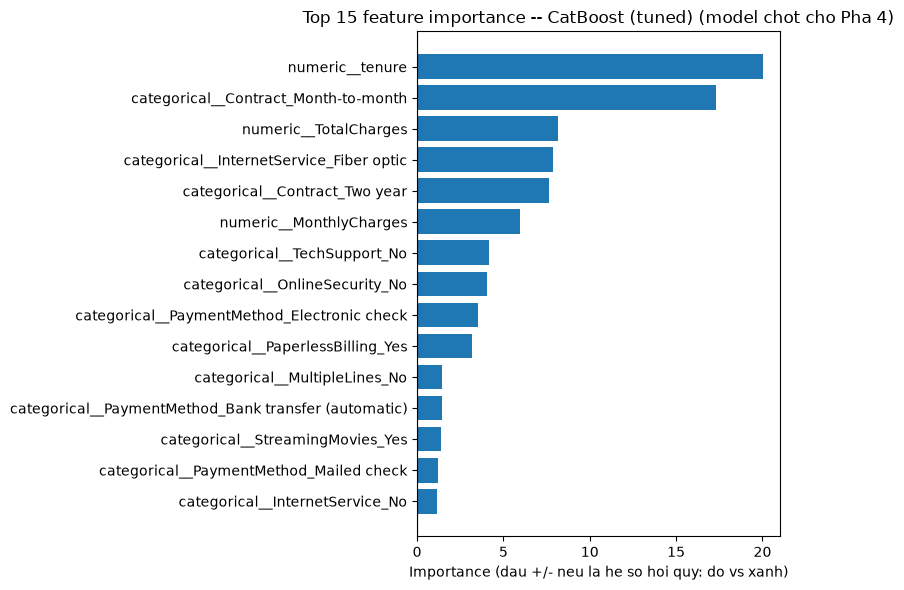

In [17]:
top_n = 15
fig, ax = plt.subplots(figsize=(8, 6))
top_features = importance_df.head(top_n).iloc[::-1]
is_linear_model = hasattr(fitted_model, "coef_")
colors = (
    ["#d62728" if v < 0 else "#1f77b4" for v in top_features["importance"]] if is_linear_model else "#1f77b4"
)
ax.barh(top_features["feature"], top_features["importance"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Top {top_n} feature importance -- {best_model_name}")
ax.set_xlabel("Importance (dau +/- neu la he so hoi quy: do vs xanh)")
plt.tight_layout()
plt.show()


## Kết luận

Model tốt nhất theo PR-AUC là **CatBoost (tuned)**, được chọn tự động trên toàn bộ candidate. Feature importance của nó đối chiếu nhất quán với EDA ở phần đầu (`tenure`, `Contract`, `InternetService`...). Bước tiếp theo là đánh giá đúng một lần trên holdout test set — dữ liệu chưa từng đụng tới trong suốt quá trình chọn/tune ở đây.